## Problem Statement



The objective of this project is to analyse HR data to assess employee performance, identify trends influencing retention, and provide recommendations for improving employee productivity and reducing turnover. Specifically, the project aims to:

● Identify performance patterns based on factors such as age, education, department, and training.

● Examine retention trends based on employee characteristics such as tenure, performance ratings, and awards.

● Provide recommendations for improving employee engagement and retention strategies by analysing the relationship between key employee metrics.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## DATA EXPLORATION

In [2]:
#load dataset

df = pd.read_csv('employees_dataset.csv')
df

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
0,8724,Technology,region_26,Bachelors,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelors,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelors,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelors,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelors,m,sourcing,1,30,4.0,7,0,0,61
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17412,64573,Technology,region_7,Bachelors,f,referred,2,30,5.0,6,1,0,81
17413,49584,HR,region_7,Bachelors,m,other,1,33,1.0,9,0,0,51
17414,49584,HR,region_7,Bachelors,m,other,1,33,1.0,9,0,0,51
17415,49584,HR,region_7,Bachelors,m,other,1,33,1.0,9,0,0,51


In [3]:
#Basic overview

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17417 entries, 0 to 17416
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   employee_id            17417 non-null  int64  
 1   department             17417 non-null  str    
 2   region                 17417 non-null  str    
 3   education              16646 non-null  str    
 4   gender                 17417 non-null  str    
 5   recruitment_channel    17417 non-null  str    
 6   no_of_trainings        17417 non-null  int64  
 7   age                    17417 non-null  int64  
 8   previous_year_rating   16054 non-null  float64
 9   length_of_service      17417 non-null  int64  
 10  KPIs_met_more_than_80  17417 non-null  int64  
 11  awards_won             17417 non-null  int64  
 12  avg_training_score     17417 non-null  int64  
dtypes: float64(1), int64(7), str(5)
memory usage: 1.7 MB


In [4]:
#Check missing values

df.isnull().sum()

employee_id                 0
department                  0
region                      0
education                 771
gender                      0
recruitment_channel         0
no_of_trainings             0
age                         0
previous_year_rating     1363
length_of_service           0
KPIs_met_more_than_80       0
awards_won                  0
avg_training_score          0
dtype: int64

In [5]:
df['education'].unique()

<StringArray>
['Bachelors', 'Masters & above', nan, 'Below Secondary']
Length: 4, dtype: str

In [6]:
#fill education nan with unknown

df['education'] = df['education'].fillna('Unknown')

In [7]:
#fill previous_year_rating nan with median

df['previous_year_rating'] = df['previous_year_rating'].fillna(df['previous_year_rating'].median())

In [8]:
#Check duplicates

df[df.duplicated()]

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
17414,49584,HR,region_7,Bachelors,m,other,1,33,1.0,9,0,0,51
17415,49584,HR,region_7,Bachelors,m,other,1,33,1.0,9,0,0,51


In [9]:
df = df.drop_duplicates()

In [10]:
#Check for anomalies

df.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
count,17415.000000,17415.000000,17415.000000,17415.000000,17415.000000,17415.000000,17415.000000,17415.000000
mean,39082.285214,1.250761,34.807982,3.318691,5.801493,0.358886,0.023371,63.177720
std,22708.049139,0.595720,7.694464,1.218216,4.175632,0.479687,0.151082,13.418314
min,3.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000
25%,19280.500000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000
50%,39115.000000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000
75%,58838.500000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,75.000000
max,78295.000000,9.000000,60.000000,5.000000,34.000000,1.000000,1.000000,99.000000


In [11]:
#Check unique values for categorical columns

cat_cols = df.select_dtypes(include='str').columns

for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].unique())


department:
<StringArray>
[       'Technology',                'HR', 'Sales & Marketing',
       'Procurement',           'Finance',         'Analytics',
        'Operations',             'Legal',               'R&D']
Length: 9, dtype: str

region:
<StringArray>
['region_26',  'region_4', 'region_13',  'region_2', 'region_29',  'region_7',
 'region_22', 'region_16', 'region_17', 'region_24', 'region_11', 'region_27',
  'region_9', 'region_20', 'region_34', 'region_23',  'region_8', 'region_14',
 'region_31', 'region_19',  'region_5', 'region_28', 'region_15',  'region_3',
 'region_25', 'region_12', 'region_21', 'region_30', 'region_10', 'region_33',
 'region_32',  'region_6',  'region_1', 'region_18']
Length: 34, dtype: str

education:
<StringArray>
['Bachelors', 'Masters & above', 'Unknown', 'Below Secondary']
Length: 4, dtype: str

gender:
<StringArray>
['m', 'f']
Length: 2, dtype: str

recruitment_channel:
<StringArray>
['sourcing', 'other', 'referred']
Length: 3, dtype: str


## KEY METRIC IDENTIFICATION

In [12]:
print("Total Employees:", df["employee_id"].nunique())


print(df["department"].value_counts())


print(df["education"].value_counts())


print(df["gender"].value_counts())

Total Employees: 17414
department
Sales & Marketing    5458
Operations           3524
Procurement          2240
Technology           2199
Analytics            1697
HR                    831
Finance               802
Legal                 332
R&D                   332
Name: count, dtype: int64
education
Bachelors          11517
Masters & above     4841
Unknown              771
Below Secondary      286
Name: count, dtype: int64
gender
m    12312
f     5103
Name: count, dtype: int64


## Performance factor 1 — Previous year rating

In [13]:
rating_performance = (
    df.groupby("previous_year_rating")
      .agg(
          employees=("employee_id", "count"),
          avg_training_score=("avg_training_score", "mean"),
          kpi_80_percent=("KPIs_met_more_than_80", "mean"),
          awards_rate=("awards_won", "mean")
      )
      .reset_index()
)


rating_performance

,previous_year_rating,employees,avg_training_score,kpi_80_percent,awards_rate
0,1.0,1974,59.870314,0.133232,0.013171
1,2.0,1292,61.678019,0.189628,0.014706
2,3.0,7176,64.011148,0.284420,0.023829
3,4.0,3156,64.289924,0.406844,0.022497
4,5.0,3817,62.909353,0.633220,0.031438


## Performance factor 2 — KPI achievement

In [14]:
kpi_analysis = (
    df.groupby("KPIs_met_more_than_80")
      .agg(
          employees=("employee_id", "count"),
          avg_training_score=("avg_training_score", "mean"),
          avg_rating=("previous_year_rating", "mean"),
          awards_rate=("awards_won", "mean")
      )
      .reset_index()
)


kpi_analysis

,KPIs_met_more_than_80,employees,avg_training_score,avg_rating,awards_rate
0,0,11165,62.456158,3.018182,0.011464
1,1,6250,64.466720,3.855520,0.044640


## Performance factor 3 — Awards

In [15]:
awards_analysis = (
    df.groupby("awards_won")
      .agg(
          employees=("employee_id", "count"),
          avg_rating=("previous_year_rating", "mean"),
          avg_training_score=("avg_training_score", "mean"),
          kpi_rate=("KPIs_met_more_than_80", "mean")
      )
      .reset_index()
)


awards_analysis

,awards_won,employees,avg_rating,avg_training_score,kpi_rate
0,0,17008,3.312206,63.016463,0.351070
1,1,407,3.589681,69.916462,0.685504


## Performance factor 4 — Training

In [16]:
training_analysis = (
    df.groupby("no_of_trainings")
      .agg(
          employees=("employee_id", "count"),
          avg_rating=("previous_year_rating", "mean"),
          awards_rate=("awards_won", "mean"),
          kpi_rate=("KPIs_met_more_than_80", "mean")
      )
      .reset_index()
)


training_analysis

,no_of_trainings,employees,avg_rating,awards_rate,kpi_rate
0,1,14059,3.345188,0.022975,0.367736
1,2,2628,3.247717,0.025495,0.333333
2,3,539,3.115028,0.022263,0.306122
3,4,137,2.846715,0.021898,0.204380
4,5,26,3.269231,0.038462,0.307692
5,6,16,2.875000,0.062500,0.000000
6,7,6,2.333333,0.000000,0.166667
7,8,2,4.500000,0.000000,0.500000
8,9,2,3.500000,0.000000,0.500000


## Performance factor 5 — Department

In [17]:
department_analysis = (
    df.groupby("department")
      .agg(
          employees=("employee_id", "count"),
          avg_rating=("previous_year_rating", "mean"),
          avg_training_score=("avg_training_score", "mean"),
          kpi_rate=("KPIs_met_more_than_80", "mean"),
          awards_rate=("awards_won", "mean"),
          avg_service=("length_of_service", "mean")
      )
      .reset_index()
)


department_analysis

,department,employees,avg_rating,avg_training_score,kpi_rate,awards_rate,avg_service
0,Analytics,1697,3.468474,84.565115,0.400118,0.025339,4.998232
1,Finance,802,3.487531,60.326683,0.397756,0.018703,5.009975
2,HR,831,3.513839,50.386282,0.361011,0.016847,5.629362
3,Legal,332,3.382530,59.533133,0.355422,0.018072,4.500000
4,Operations,3524,3.631385,60.351589,0.440692,0.025255,6.429342
5,Procurement,2240,3.234375,70.180357,0.373214,0.025446,6.187500
6,R&D,332,3.659639,84.451807,0.448795,0.015060,4.798193
7,Sales & Marketing,5458,3.096189,50.056614,0.277208,0.021986,5.753023
8,Technology,2199,3.143702,79.847658,0.356071,0.026376,5.844020


## Performance factor 6 — Age

In [18]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[20, 30, 40, 50, 60],
    labels=["20-30", "30-40", "40-50", "50-60"]
)

In [19]:
age_analysis = (
    df.groupby("age_group", observed=True)
      .agg(
          employees=("employee_id", "count"),
          avg_rating=("previous_year_rating", "mean"),
          avg_training_score=("avg_training_score", "mean"),
          kpi_rate=("KPIs_met_more_than_80", "mean")
      )
      .reset_index()
)


age_analysis

,age_group,employees,avg_rating,avg_training_score,kpi_rate
0,20-30,5746,3.245910,63.787330,0.364601
1,30-40,8223,3.349629,63.155175,0.368357
2,40-50,2474,3.357316,61.892078,0.331447
3,50-60,930,3.398925,63.254839,0.317204


## Performance factor 7 — Education

In [20]:
education_analysis = (
    df.groupby("education")
      .agg(
          employees=("employee_id", "count"),
          avg_rating=("previous_year_rating", "mean"),
          avg_training_score=("avg_training_score", "mean"),
          kpi_rate=("KPIs_met_more_than_80", "mean"),
          awards_rate=("awards_won", "mean")
      )
      .reset_index()
    
)

education_analysis

,education,employees,avg_rating,avg_training_score,kpi_rate,awards_rate
0,Bachelors,11517,3.311800,63.035426,0.357993,0.022923
1,Below Secondary,286,3.367133,65.902098,0.465035,0.031469
2,Masters & above,4841,3.368519,64.134270,0.368312,0.025615
3,Unknown,771,3.090791,58.286641,0.273671,0.012970


## Performance factor 8 — Length of service

In [21]:
service_analysis = (
    df.groupby("length_of_service")
      .agg(
          employees=("employee_id", "count"),
          avg_rating=("previous_year_rating", "mean"),
          avg_training_score=("avg_training_score", "mean"),
          kpi_rate=("KPIs_met_more_than_80", "mean"),
          awards_rate=("awards_won", "mean")
      )
      .reset_index()
)

service_analysis

,length_of_service,employees,avg_rating,avg_training_score,kpi_rate,awards_rate
0,1,1498,3.025367,63.253004,0.365821,0.024032
1,2,2094,3.328558,63.425501,0.385864,0.031041
2,3,2249,3.330814,63.170743,0.395731,0.028902
3,4,2162,3.337188,63.897317,0.374653,0.026364
4,5,1914,3.325496,63.437827,0.386625,0.025601
5,6,1497,3.358049,63.678691,0.389446,0.025384
6,7,1773,3.357022,62.874224,0.385787,0.027073
7,8,933,3.371919,63.060021,0.289389,0.011790
8,9,799,3.394243,62.242804,0.306633,0.016270
9,10,697,3.325681,62.358680,0.298422,0.010043


## Create a performance-risk group

In [22]:
df["performance_concern"] = (
    (df["previous_year_rating"] <= 2) &
    (df["KPIs_met_more_than_80"] == 0) &
    (df["avg_training_score"] < df["avg_training_score"].median())
)
df

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score,age_group,performance_concern
0,8724,Technology,region_26,Bachelors,m,sourcing,1,24,3.0,1,1,0,77,20-30,False
1,74430,HR,region_4,Bachelors,f,other,1,31,3.0,5,0,0,51,30-40,False
2,72255,Sales & Marketing,region_13,Bachelors,m,other,1,31,1.0,4,0,0,47,30-40,True
3,38562,Procurement,region_2,Bachelors,f,other,3,31,2.0,9,0,0,65,30-40,False
4,64486,Finance,region_29,Bachelors,m,sourcing,1,30,4.0,7,0,0,61,20-30,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17410,57239,Sales & Marketing,region_31,Bachelors,m,other,1,42,3.0,10,0,0,53,40-50,False
17411,73858,Sales & Marketing,region_25,Bachelors,m,sourcing,2,28,2.0,5,0,0,45,20-30,True
17412,64573,Technology,region_7,Bachelors,f,referred,2,30,5.0,6,1,0,81,20-30,False
17413,49584,HR,region_7,Bachelors,m,other,1,33,1.0,9,0,0,51,30-40,True


In [23]:
df["performance_concern"].value_counts()

performance_concern
False    15830
True      1585
Name: count, dtype: int64

## Retention-risk proxy

In [24]:
# Longer service + weak KPI achievement + low previous rating

df["retention_risk_proxy"] = (
    (df["length_of_service"] > df["length_of_service"].median()) &
    (df["KPIs_met_more_than_80"] == 0) &
    (df["previous_year_rating"] <= 2)
)
df

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score,age_group,performance_concern,retention_risk_proxy
0,8724,Technology,region_26,Bachelors,m,sourcing,1,24,3.0,1,1,0,77,20-30,False,False
1,74430,HR,region_4,Bachelors,f,other,1,31,3.0,5,0,0,51,30-40,False,False
2,72255,Sales & Marketing,region_13,Bachelors,m,other,1,31,1.0,4,0,0,47,30-40,True,False
3,38562,Procurement,region_2,Bachelors,f,other,3,31,2.0,9,0,0,65,30-40,False,True
4,64486,Finance,region_29,Bachelors,m,sourcing,1,30,4.0,7,0,0,61,20-30,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17410,57239,Sales & Marketing,region_31,Bachelors,m,other,1,42,3.0,10,0,0,53,40-50,False,False
17411,73858,Sales & Marketing,region_25,Bachelors,m,sourcing,2,28,2.0,5,0,0,45,20-30,True,False
17412,64573,Technology,region_7,Bachelors,f,referred,2,30,5.0,6,1,0,81,20-30,False,False
17413,49584,HR,region_7,Bachelors,m,other,1,33,1.0,9,0,0,51,30-40,True,True


In [25]:
df["retention_risk_proxy"].value_counts() 

retention_risk_proxy
False    16100
True      1315
Name: count, dtype: int64

"Retention risk proxy identifies employees with longer tenure and weaker performance indicators. Since the dataset does not contain actual attrition information, this should be interpreted as a potential retention concern rather than a prediction of employee turnover."

## Find retention concerns by department

In [26]:
retention_department = (
    df.groupby("department")
      .agg(
          employees=("employee_id", "count"),
          retention_concern_count=("retention_risk_proxy", "sum")
      )
      .reset_index()
)

retention_department["retention_concern_rate"] = (
    retention_department["retention_concern_count"] /
    retention_department["employees"] * 100
)

retention_department.sort_values(
    "retention_concern_rate",
    ascending=False
)

,department,employees,retention_concern_count,retention_concern_rate
7,Sales & Marketing,5458,624,11.432759
8,Technology,2199,195,8.867667
5,Procurement,2240,177,7.901786
3,Legal,332,21,6.325301
2,HR,831,38,4.572804
4,Operations,3524,161,4.568672
0,Analytics,1697,65,3.830289
1,Finance,802,25,3.117207
6,R&D,332,9,2.710843


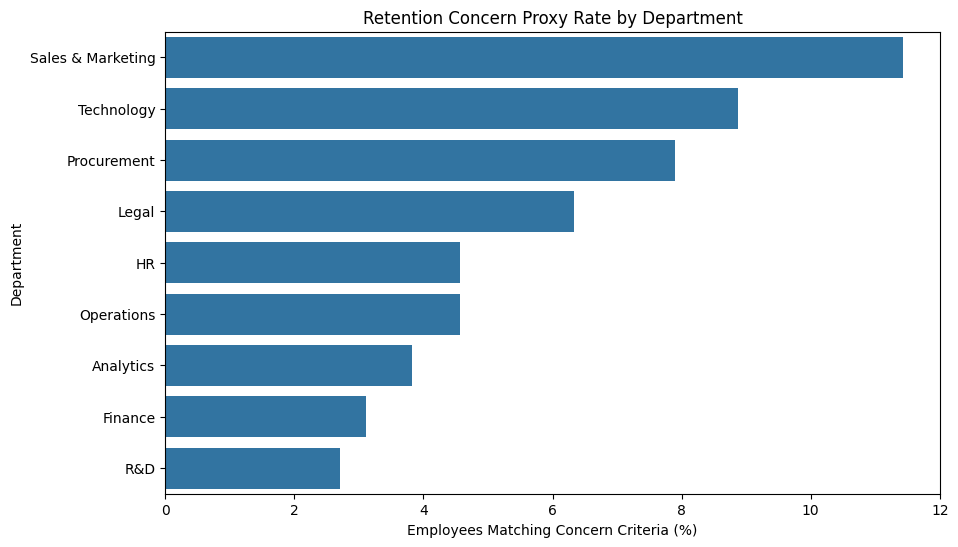

In [27]:
retention_dept = (
    df.groupby("department")["retention_risk_proxy"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=retention_dept,
    x="retention_risk_proxy",
    y="department"
)

plt.title("Retention Concern Proxy Rate by Department")
plt.xlabel("Employees Matching Concern Criteria (%)")
plt.ylabel("Department")
plt.show()

## Department vs performance score

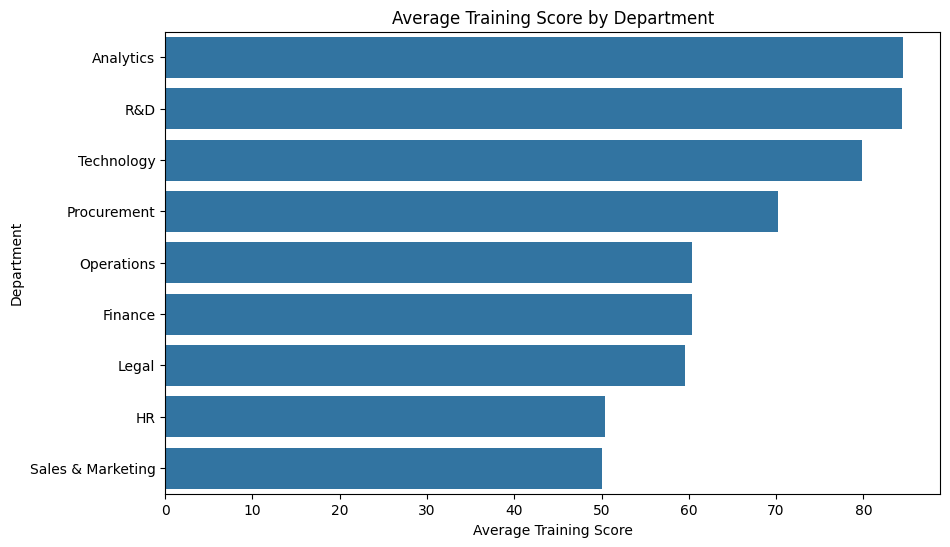

In [28]:
dept_score = (
    df.groupby("department")["avg_training_score"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=dept_score,
    x="avg_training_score",
    y="department"
)

plt.title("Average Training Score by Department")
plt.xlabel("Average Training Score")
plt.ylabel("Department")
plt.show()

## Length of service vs performance

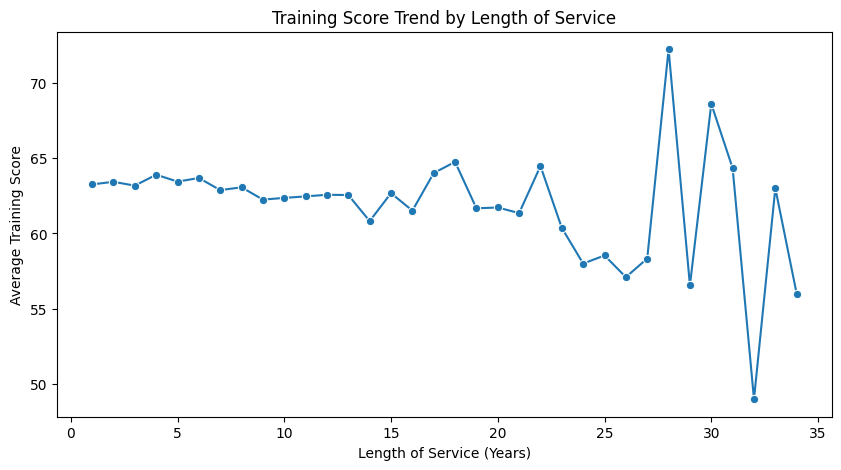

In [29]:
service_score = (
    df.groupby("length_of_service")["avg_training_score"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=service_score,
    x="length_of_service",
    y="avg_training_score",
    marker="o"
)

plt.title("Training Score Trend by Length of Service")
plt.xlabel("Length of Service (Years)")
plt.ylabel("Average Training Score")
plt.show()

## Key findings from the outputs

Rating, KPI and awards all move together.

More trainings correlate with worse outcomes.

Department gaps are large: Analytics and R&D average ~84 training score, Sales & Marketing and HR ~50. Operations and R&D lead on KPI rate; Sales & Marketing trails at 28%.

Age and education have weak effects; the "Unknown" education group is the weakest, which is a data-quality artefact rather than a real signal.


Performance-concern group: 1,585 employees (9%). Retention-risk proxy: 1,315 (7.6%), concentrated in Sales & Marketing (11.4%), Technology (8.9%) and Procurement (7.9%).